# 05 · Current-meter data — water velocity

This notebook uses the **other** dataset: the `currentmeter/` folder, which holds
a seafloor **current meter**. Unlike the pressure gauge (a single number), a
current meter measures the **velocity of the water** — a *vector* — broken into
three components:

| channel | component | meaning | units |
|---------|-----------|---------|-------|
| `LOE` | **east**  | + = flowing east  | m/s |
| `LON` | **north** | + = flowing north | m/s |
| `LOZ` | **up**    | + = flowing upward | m/s |
| `LKO` | temperature | — | °C |

From the east/north pair we get the two numbers people usually want: **speed**
(how fast) and **direction** (which way). This notebook builds the standard
current-meter views from those.

> 🎯 **What you'll learn in this notebook**
>
> - Load 3-component velocity into one tidy table with `ol.load_current`
> - Convert east/north into speed & direction
> - Read a stick (vector) plot and a progressive vector diagram
> - Read a current rose (where the water goes, how fast)
> - Relate the currents to the tide from notebook 04

> ❓ **Questions to answer**
>
> Work these out yourself as you go — jot your answers in a new cell. The recap at the end lets you check.
>
> 1. Which compass direction does the current mostly flow along? Does it reverse back-and-forth or rotate?
> 2. How fast is a typical current here? Is that big or small compared with surface ocean currents?
> 3. Does the current speed pulse in step with the tide? When in the tidal cycle is it fastest?
> 4. From the progressive vector diagram, is there a net drift, or mostly tidal sloshing?

> ⚠️ **Data note (read me).** This is a *partial download* — right now the
> current meter data is essentially all from one station (**HYSB1**); more
> stations will arrive later. Everything below **discovers the available stations
> automatically** (`ol.current_stations()`), so it will just work when they do.
> The loader also runs **quality control**: bottom currents here are well under
> 1 m/s, so any sample faster than `ol.CUR_QC_MAX` (3 m/s) is treated as a
> fill/spike value and masked out.

In [1]:
# --- Standard scientific-Python toolkit -----------------------------------
import warnings; warnings.filterwarnings("ignore")  # hide harmless library chatter
import numpy as np                 # arrays & math
import pandas as pd                # labelled time series (our main data type)
import matplotlib.pyplot as plt    # plotting
import matplotlib.dates as mdates  # nice date axes
import oceanlib as ol              # OUR helper module (sits next to this notebook)

# Make every plot a sensible default size with a light grid.
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})
pd.set_option("display.max_rows", 40)

print("Reading data from:", ol.DATA_DIR)
print("Stations available:", ol.STATIONS)

Reading data from: /Users/quakehunter/Documents/data_exploration/tidal
Stations available: ['AXBA1', 'HYSB1', 'HYS14']


In [2]:
print("Current-meter stations available:", ol.current_stations())
STATION = ol.primary_current_station()     # the station with the most data (auto)
win = ol.current_window(STATION)            # a clean, gap-free window for it (auto)
print("Using station:", STATION, "| window:", win)

Current-meter stations available: ['HYS14', 'HYSB1']
Using station: HYSB1 | window: {'start': '2018-10-02', 'end': '2019-04-19'}


## What the loaded data looks like

`ol.load_current` returns a tidy DataFrame: one row per time, columns for each
velocity component plus derived `speed` and `dir`. Let's load one day at full
1-second resolution.

In [3]:
day = pd.Timestamp(win["start"]) + pd.Timedelta(days=10)
cur = ol.load_current(STATION, day, day)        # full-rate, one day
cur[["east", "north", "up", "speed", "dir"]].describe().round(3)

,east,north,up,speed,dir
count,86395.000,86395.000,86395.000,86395.000,86395.000
mean,0.013,-0.006,0.004,0.034,138.913
std,0.013,0.032,0.003,0.015,104.282
min,-0.035,-0.084,-0.015,0.000,0.000
25%,0.003,-0.036,0.002,0.024,38.950
50%,0.012,-0.004,0.004,0.032,143.099
75%,0.022,0.024,0.007,0.045,164.873
max,0.061,0.056,0.024,0.086,359.969


> 👀 **What you're seeing**
>
> `east`/`north`/`up` are velocities in m/s and can be **negative** (west/south/down). `speed` = √(east²+north²) is the horizontal current strength (always ≥ 0). `dir` is the compass heading the water flows *toward* (0°=N, 90°=E). Speeds here are small (centimetres/second) — typical for the deep seafloor.

## The three velocity components over one day

saved /Users/quakehunter/Documents/data_exploration/figures/05_HYSB1_components_day.png


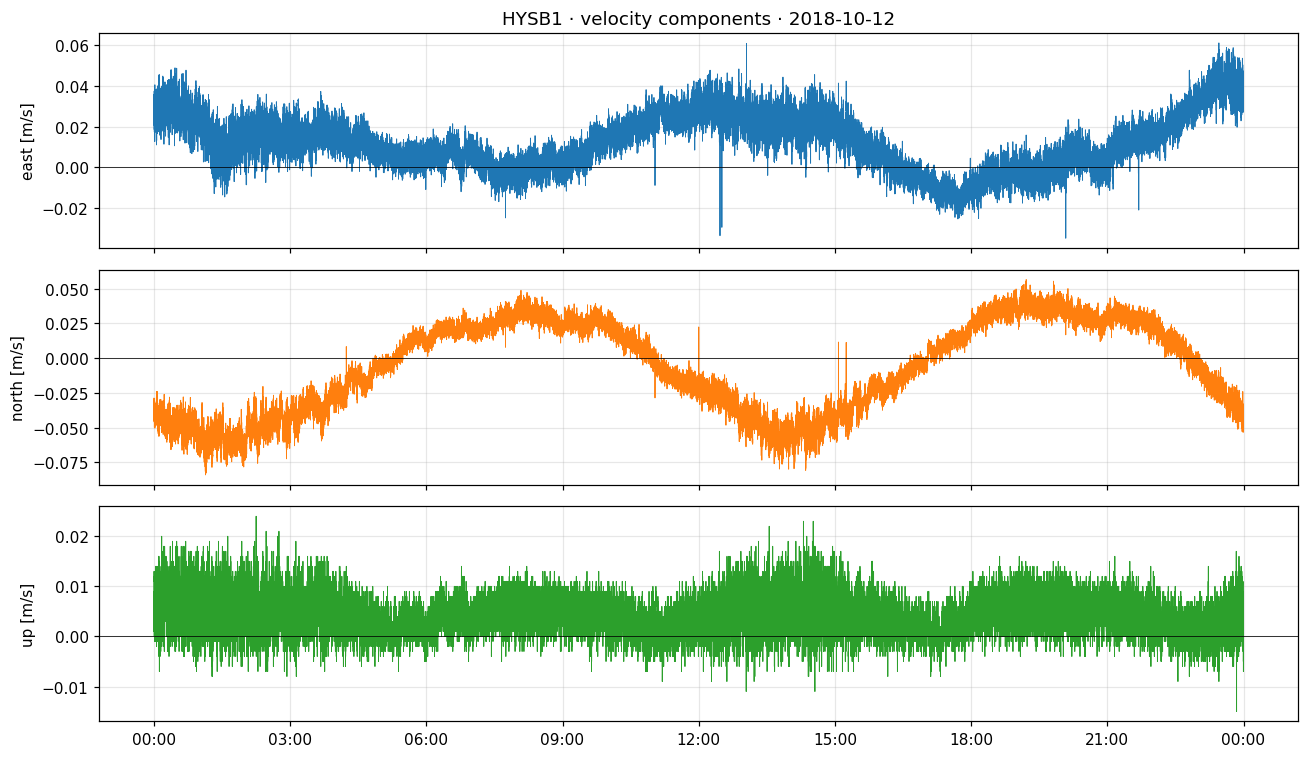

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, comp, c in zip(axes, ["east", "north", "up"], ["C0", "C1", "C2"]):
    ax.plot(cur.index, cur[comp], c, lw=0.6)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(f"{comp} [m/s]")
axes[0].set_title(f"{STATION} · velocity components · {day.date()}")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout(); ol.savefig(fig, f"05_{STATION}_components_day.png"); plt.show()

> 👀 **What you're seeing**
>
> Each component swings above and below zero. If the swings have a ~12-hour rhythm, that's the **tidal current** — the same tide from notebook 04, but now we see it pushing water back and forth, not just up and down.

## Speed and direction

saved /Users/quakehunter/Documents/data_exploration/figures/05_HYSB1_speed_dir_day.png


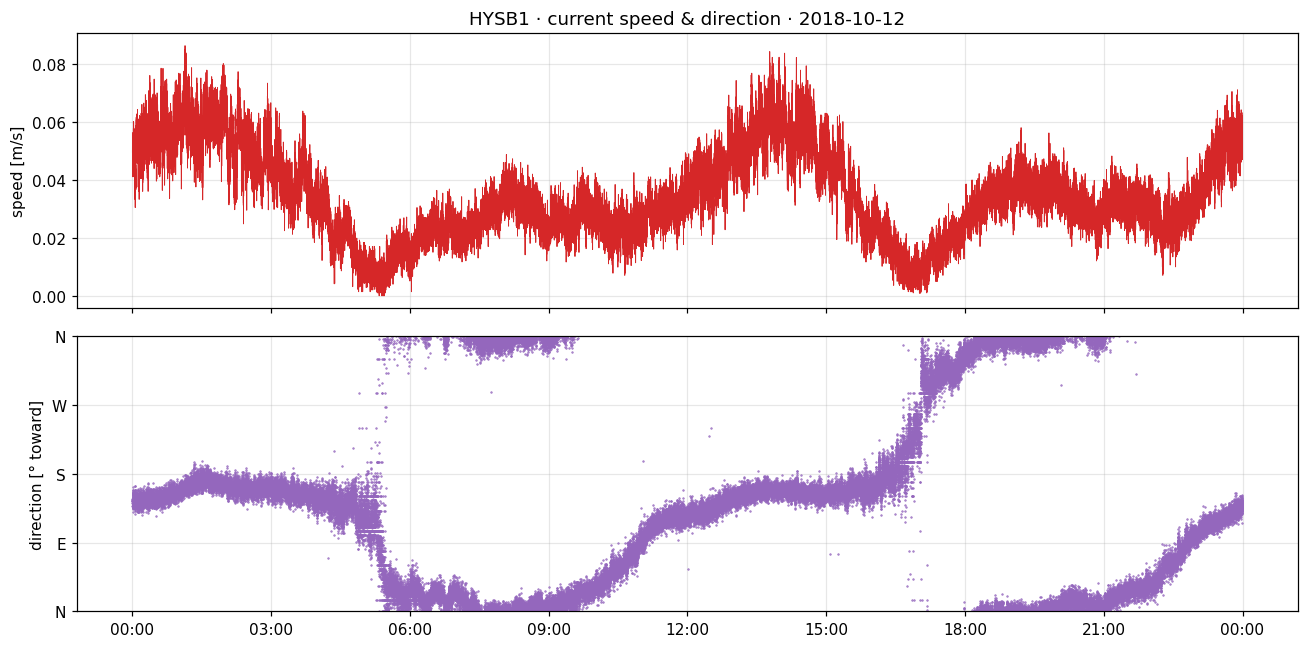

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(cur.index, cur["speed"], "C3", lw=0.6); axes[0].set_ylabel("speed [m/s]")
axes[1].plot(cur.index, cur["dir"], ".", ms=1, color="C4"); axes[1].set_ylabel("direction [° toward]")
axes[1].set_ylim(0, 360); axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].set_yticklabels(["N", "E", "S", "W", "N"])
axes[0].set_title(f"{STATION} · current speed & direction · {day.date()}")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout(); ol.savefig(fig, f"05_{STATION}_speed_dir_day.png"); plt.show()

> 👀 **What you're seeing**
>
> When the tide reverses, speed dips toward zero (slack water) and the direction flips by ~180° — the classic back-and-forth of a tidal current. Direction is plotted as dots because it's meaningless to draw a line across the 360°→0° wrap.

## Stick (vector) plot

A stick plot draws the current as little arrows along the time axis — the
clearest single picture of a current record. Each arrow points the way the water
is flowing and its length is the speed. We thin to one arrow per ~30 min so they
don't overlap.

saved /Users/quakehunter/Documents/data_exploration/figures/05_HYSB1_stickplot.png


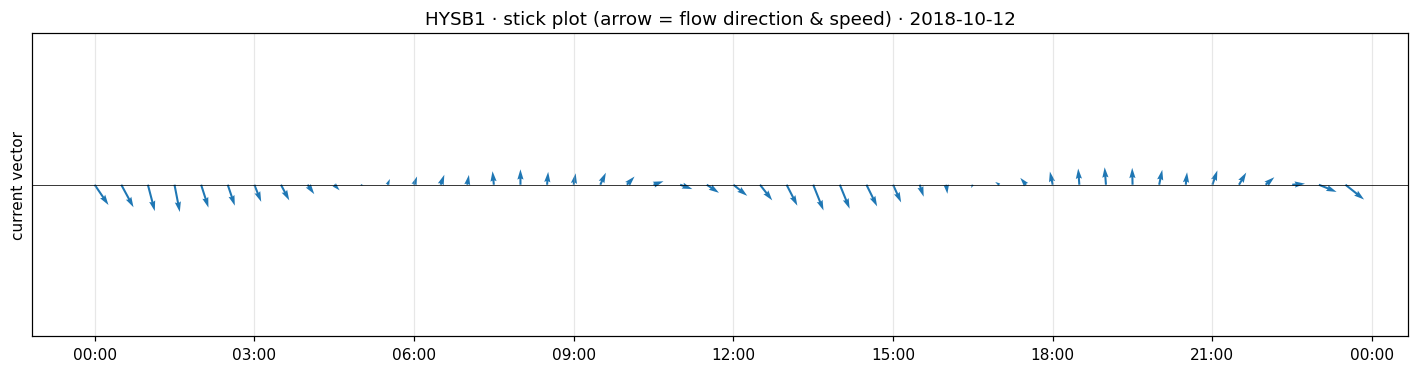

In [6]:
s = cur.resample("30min").mean().dropna(subset=["east", "north"])
fig, ax = plt.subplots(figsize=(13, 3.5))
t = mdates.date2num(s.index.to_pydatetime())
ax.quiver(t, np.zeros(len(s)), s["east"], s["north"],
          angles="uv", scale=3, width=0.0015, color="C0")
ax.axhline(0, color="k", lw=0.5)
ax.set_yticks([]); ax.set_ylabel("current vector")
ax.set_title(f"{STATION} · stick plot (arrow = flow direction & speed) · {day.date()}")
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout(); ol.savefig(fig, f"05_{STATION}_stickplot.png"); plt.show()

> 👀 **What you're seeing**
>
> Arrows pointing up = water heading north, right = east, etc. Watch them swing back and forth (or rotate) over the tidal cycle. A steady lean in one direction across the whole day is the *mean* (non-tidal) current.

## Progressive vector diagram — *where would a water parcel go?*

If you follow the current and add up all its little steps (velocity × time), you
trace the path a drifting parcel of water *would* take. It's not a real
trajectory (the meter sits still), but it's a great way to see net transport.
We use the longer window here, decimated to 10-minute steps.

saved /Users/quakehunter/Documents/data_exploration/figures/05_HYSB1_progressive_vector.png


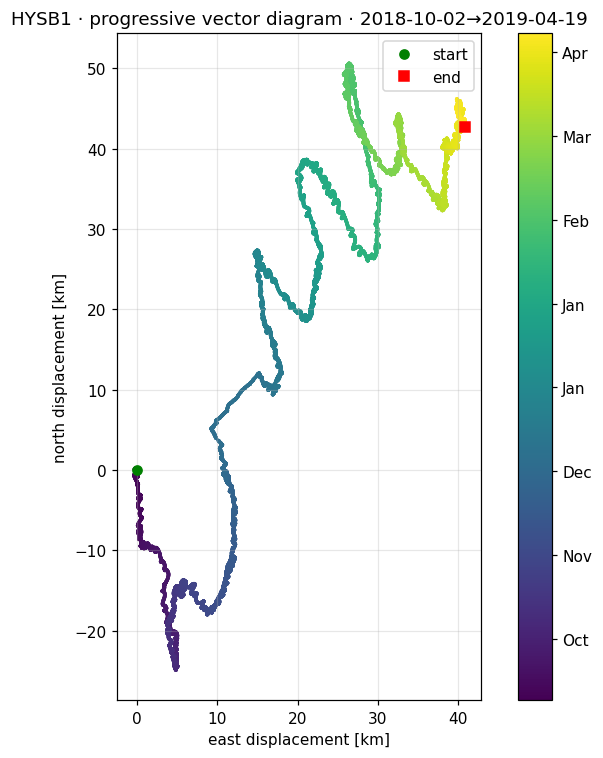

In [7]:
trk = ol.load_current(STATION, win["start"], win["end"], rule="10min").dropna(subset=["east", "north"])
dt = 600.0  # seconds per 10-min step
# integrate velocity -> displacement, convert m -> km
x = (trk["east"] * dt).cumsum() / 1000.0
y = (trk["north"] * dt).cumsum() / 1000.0

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(x, y, c=mdates.date2num(trk.index.to_pydatetime()), s=2, cmap="viridis")
ax.plot(x.iloc[0], y.iloc[0], "go", label="start"); ax.plot(x.iloc[-1], y.iloc[-1], "rs", label="end")
ax.set_aspect("equal"); ax.set_xlabel("east displacement [km]"); ax.set_ylabel("north displacement [km]")
ax.legend(); ax.set_title(f"{STATION} · progressive vector diagram · {win['start']}→{win['end']}")
cb = fig.colorbar(sc, ax=ax); cb.ax.yaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout(); ol.savefig(fig, f"05_{STATION}_progressive_vector.png"); plt.show()

> 👀 **What you're seeing**
>
> Tight loops/zig-zags are the tide sloshing back and forth (no net travel). A steady drift of the whole curve in one direction is the **mean current** carrying water that way over weeks. The colour shows time, so you can see how the net direction evolves.

## Current rose — the direction/speed climate

A current rose is a polar histogram: each wedge points in a compass direction,
its length is how *often* the current flowed that way, and the colours split that
by speed. It summarises months of data in one picture.

saved /Users/quakehunter/Documents/data_exploration/figures/05_HYSB1_current_rose.png


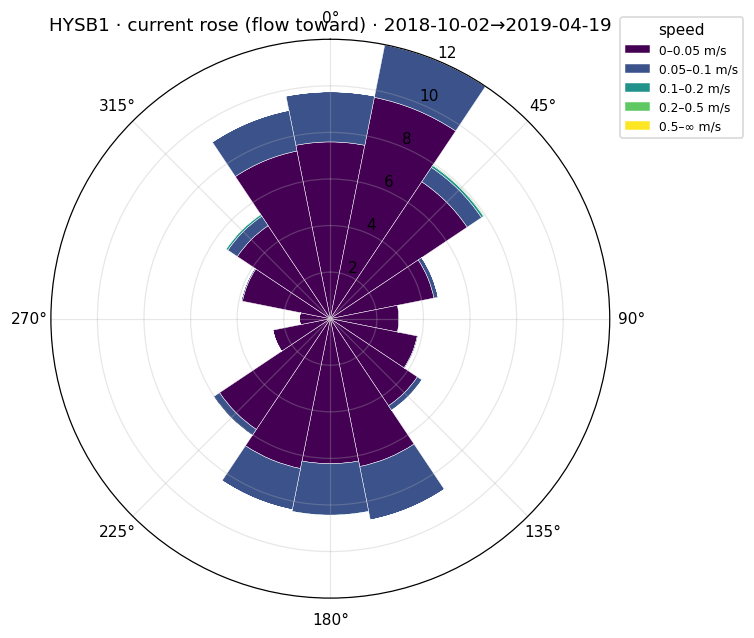

In [8]:
rose = ol.load_current(STATION, win["start"], win["end"], rule="10min").dropna(subset=["speed", "dir"])
nbins = 16
ang = np.deg2rad(np.arange(0, 360, 360 / nbins))
width = 2 * np.pi / nbins
spd_bins = [0, 0.05, 0.1, 0.2, 0.5, np.inf]
colors = plt.cm.viridis(np.linspace(0, 1, len(spd_bins) - 1))

fig = plt.figure(figsize=(7, 7)); ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)   # compass: N up, clockwise
# which direction-wedge each sample falls in (centred on each compass point)
dir_bin = ((((rose["dir"] + 360 / nbins / 2) % 360) // (360 / nbins)).astype(int)) % nbins
bottom = np.zeros(nbins)
for k in range(len(spd_bins) - 1):
    lo, hi = spd_bins[k], spd_bins[k + 1]
    sel = (rose["speed"] >= lo) & (rose["speed"] < hi)
    counts = np.bincount(dir_bin[sel], minlength=nbins)
    frac = 100 * counts / len(rose)                       # % of all samples
    lbl = f"{lo}–{hi if np.isfinite(hi) else '∞'} m/s"
    ax.bar(ang, frac, width=width, bottom=bottom, color=colors[k],
           edgecolor="w", linewidth=0.3, label=lbl)
    bottom += frac
ax.set_title(f"{STATION} · current rose (flow toward) · {win['start']}→{win['end']}")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), fontsize=8, title="speed")
plt.tight_layout(); ol.savefig(fig, f"05_{STATION}_current_rose.png"); plt.show()

> 👀 **What you're seeing**
>
> Long wedges show the directions the current most often flows toward; if two opposite wedges dominate, the flow is a back-and-forth tidal jet aligned with that axis. The colour mix tells you whether the fast events come from a particular direction.

## Do the currents follow the tide?

Notebook 04 found the tide in **pressure**. Here we overlay current **speed**
against the **pressure** record over the same window — if the current is tidal,
its speed should pulse in step with the rise and fall of the tide.

saved /Users/quakehunter/Documents/data_exploration/figures/05_HYSB1_current_vs_tide.png


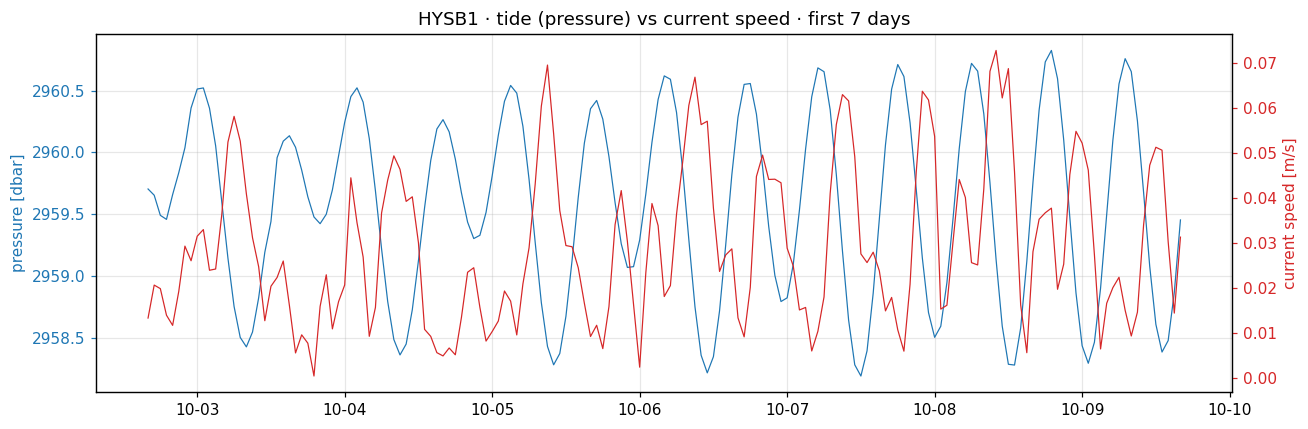

4712 overlapping hours of current + pressure.


In [9]:
a, b = win["start"], win["end"]
spd = ol.load_current(STATION, a, b, rule="1h")["speed"]
press = ol.load_decimated(STATION, "pressure", a, b, rule="1h")
both = pd.concat({"speed": spd, "pressure": press}, axis=1).dropna()

if len(both) > 100:
    zoom = both.loc[both.index[0]:both.index[0] + pd.Timedelta(days=7)]
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(zoom.index, zoom["pressure"], "C0", lw=0.8)
    ax1.set_ylabel("pressure [dbar]", color="C0"); ax1.tick_params(axis="y", colors="C0")
    ax2 = ax1.twinx(); ax2.plot(zoom.index, zoom["speed"], "C3", lw=0.8)
    ax2.set_ylabel("current speed [m/s]", color="C3"); ax2.tick_params(axis="y", colors="C3"); ax2.grid(False)
    ax1.set_title(f"{STATION} · tide (pressure) vs current speed · first 7 days")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    plt.tight_layout(); ol.savefig(fig, f"05_{STATION}_current_vs_tide.png"); plt.show()
    print(f"{len(both)} overlapping hours of current + pressure.")
else:
    print("Not enough overlapping current+pressure data in this window "
          f"({len(both)} hrs) — likely a different station/period once more data lands.")

> 👀 **What you're seeing**
>
> Tidal currents typically run *fastest midway between* high and low tide (when the water is moving most) and go slack at the turning points — so current-speed peaks often sit between the pressure peaks and troughs. A formal version of this is harmonic analysis of the east/north components (tidal-current ellipses) — the same Thomson & Emery machinery from notebook 04, applied to velocity.

> ✏️ **Try it yourself**
>
> 1. Re-run with a different station once more data arrives: set `STATION = 'HYS14'`.
> 2. Change the stick-plot `day` to a spring vs a neap day — are the arrows longer at spring?
> 3. In the progressive vector diagram, switch `rule` to '1h' — does the net path change shape?
> 4. Compute the mean current vector for the whole window: `cur[['east','north']].mean()` — which way does the water go on average?

> ✅ **Recap**
>
> You loaded 3-component current-meter velocity (with automatic QC and station discovery), turned it into speed/direction, and read it as components, a stick plot, a progressive vector diagram, and a current rose — then tied the currents back to the tide. The code scales to new stations automatically as your downloads complete.
>
> ➡️ **Next:** add more stations to `currentmeter/`, then just re-run — or extend this into tidal-current-ellipse harmonic analysis.